第四章 word2vec的高速化
========

<div class="alert alert-block alert-info">
不要企图无所不知，否则你将一无所知
    
  ——德谟克利特（古希腊哲学家）
</div>

## word2vec的改进1

我们先复习一下上一章的内容。在上一章中，我们实现了图中的CBOW 模型

假设词汇量有 100 万个，CBOW 模型的中间层神经元有 100 个，此时 word2vec 进行的处理如图所示

![](../../images/4-2.png)

1. H=WinX

2. S = HWout

3. Y = Softmax with loss（S）

重点关注这三个计算大户

### Embedding层

针对计算大户

![](../../images/4-3.png)

我反应过来了，我们要的h，其实就是在Win中取出跟X对应的那一行即可

那用不着dot，直接取就行了

这个我们给他起名叫Embedding层

### Embedding层的实现

先看W中取出指定一行

In [118]:
import numpy as np
W = np.arange(21).reshape(7, 3)
W

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14],
       [15, 16, 17],
       [18, 19, 20]])

In [119]:
W[2]

array([6, 7, 8])

In [120]:
 W[5]

array([15, 16, 17])

用索引就可以了so easy

然后从 W 中一次性提取多行

In [121]:
idx = np.array([1, 0, 3, 0])
W[idx]

array([[ 3,  4,  5],
       [ 0,  1,  2],
       [ 9, 10, 11],
       [ 0,  1,  2]])

实现Embedding层

初始化

In [122]:
# common/layers.py
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

In [123]:
W = np.arange(21).reshape(7, 3)
embed = Embedding(W)

In [124]:
embed.params

[array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]])]

In [125]:
embed.grads

[array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])]

In [126]:
embed.idx

正向传播

In [127]:
# common/layers.py
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
        
    def forward(self, idx):
        W, = self.params # 注意一下这个逗号，是把列表里面的值取出来 array
        self.idx = idx
        out = W[idx]
        return out

In [128]:
W = np.arange(21).reshape(7, 3)
embed = Embedding(W)

In [129]:
a, = embed.params

In [130]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14],
       [15, 16, 17],
       [18, 19, 20]])

In [131]:
embed.forward(2)

array([6, 7, 8])

In [132]:
embed.idx

2

![](../../images/4-4.png)

再看一下反向传播

In [133]:
# common/layers.py
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
        
    def forward(self, idx):
        W, = self.params # 注意一下这个逗号，是把列表里面的值取出来 array
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
        dW[self.idx] = dout # 不太好的方式
        return None

In [134]:
W = np.arange(21).reshape(7, 3)
embed = Embedding(W)

In [135]:
embed.forward(2)

array([6, 7, 8])

In [136]:
dout = 3

In [137]:
dW, = embed.grads # 注意这里grads会跟着改变
dW

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]])

In [138]:
dW[...] = 0
dW

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]])

In [139]:
embed.grads 

[array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])]

In [140]:
embed.idx

2

In [141]:
dW[embed.idx] = dout # 不太好的方式

In [142]:
dW

array([[0, 0, 0],
       [0, 0, 0],
       [3, 3, 3],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]])

In [143]:
embed.grads # 此时grads已经改变

[array([[0, 0, 0],
        [0, 0, 0],
        [3, 3, 3],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])]

这里，取出权重梯度 dW，通过 dW[...] = 0 将 dW 的元素设为 0（并不是将 dW 设为 0，而是保持 dW 的形状不变，将它的元素设为 0）。

然后，将上一层传来的梯度 dout 写入 idx 指定的行。

这里有一个问题

在 idx 的元素出现重复时。比如，当 idx 为 [0, 2, 0, 4] 时，会出现覆盖的情况

In [144]:
embed = Embedding(W)
embed.params

[array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]])]

In [145]:
embed.forward(np.array([0, 2, 0, 4]))

array([[ 0,  1,  2],
       [ 6,  7,  8],
       [ 0,  1,  2],
       [12, 13, 14]])

In [146]:
embed.backward(3)

In [147]:
embed.grads

[array([[3, 3, 3],
        [0, 0, 0],
        [3, 3, 3],
        [0, 0, 0],
        [3, 3, 3],
        [0, 0, 0],
        [0, 0, 0]])]

0这个明明有两个，但是跟一个没去别

![](../../images/4-5.png)

为了解决这个重复问题，需要进行“加法”，而不是“写入”

In [148]:
# common/layers.py
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
        
    def forward(self, idx):
        W, = self.params # 注意一下这个逗号，是把列表里面的值取出来 array
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
#         for i, word_id in enumerate(self.idx):
#             dW[word_id] += dout[i]
#       或者
        np.add.at(dW, self.idx, dout)
        return None

In [149]:
embed = Embedding(W)
embed.params

[array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]])]

In [150]:
embed.forward(np.array([0, 2, 0, 4]))

array([[ 0,  1,  2],
       [ 6,  7,  8],
       [ 0,  1,  2],
       [12, 13, 14]])

导数的形状跟forward输出的形状一致

In [151]:
dout = np.zeros((4,3), dtype=np.int32) # 注意这里必须定义32位
dout[...] = int(3)
dout

array([[3, 3, 3],
       [3, 3, 3],
       [3, 3, 3],
       [3, 3, 3]], dtype=int32)

In [152]:
embed.backward(dout)

In [153]:
embed.grads

[array([[6, 6, 6],
        [0, 0, 0],
        [3, 3, 3],
        [0, 0, 0],
        [3, 3, 3],
        [0, 0, 0],
        [0, 0, 0]])]

这里可以看到，0位置的梯度被累加

此外，这里使用 for 循环语句的实现也可以通过 NumPy 的 np.add.at() 进行。

np.add.at(A, idx, B) 将 B 加到 A 上，此时可以通过 idx 指定 A 中需要进行加法的行。

<div class="alert alert-success" role="alert">
    <strong>冷静</strong> 
考虑一下为什么是加法

![](../../images/tuidao4-1.jpg)

## word2vec的改进2

三个问题

```
1. H = WinX

2. S = HWout

3. Y = Softmax with loss（S）

```

问题1已解决，下面是问题2和问题3

### 中间层之后的计算问题

![](../../images/4-6.png)

![](../../images/4.1.png)

2. S = HWout

3. Y = Softmax with loss（S）

可以看到，问题2与问题3的计算量都跟词汇量相关

下面我们要实现一种方法，无论词汇量多大，都能使得计算量保持较低或者恒定

### 从多分类到二分类

考虑用二分类拟合多分类

多分类：给you和goodbye，目标词是谁？

二分类：“当上下文是 you 和 goodbye 时，目标词是 say 吗？

那么我们的计算就变成下图

![](../../images/4-7.png)

![](../../images/4-8.png)

### sigmoid函数和交叉熵误差

二分类用sigmoid拟合概率

![](../../images/4.2.png)

反向求导如下

![](../../images/4-9.png)

损失函数交叉熵误差

![](../../images/4.3.png)

t = 1时，-logy

t = 0时， -log(1-y)

sigmoid 与 CrossEntropy Error合成一个层

![](../../images/4-10.png)

这个推导上本书都推过了

### 多分类到二分类的实现

回顾一下，多分类的情况

![](../../images/4-11.png)

改成二分类的情况

![](../../images/4-12.png)

二分类这个快合并一个Embedding Dot层

![](../../images/4-13.png)

实现这个层

初始化

In [154]:
import numpy as np

In [155]:
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W) # 这里生成了Embedding层
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

- params 保存参数

- grads 保存梯度

- 另外，作为缓存，embed 保存 Embedding 层

- cache 保存正向传播时的计算结果

In [156]:
Wout = np.arange(21).reshape(7, 3)
embeddot = EmbeddingDot(Wout)

In [157]:
embeddot.params

[array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]])]

In [158]:
embeddot.grads

[array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])]

In [159]:
embeddot.cache

forward

In [160]:
# ch04/negative_sampling_layer.py
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W) # 这里生成了Embedding层
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None
        
    def forward(self, h, idx):
        target_W = self.embed.forward(idx) # Wout对应的列
        out = np.sum(target_W * h, axis=1)
        self.cache = (h, target_W)
        return out

out = np.sum(target_W * h, axis=1) 是怎么回事

![](../../images/bq17.jpg)

对这里  的解释，书上给了这么一张图

![](../../images/4-14.png)

书上的文字稍微有点困惑，我是这样理解的

![](../../images/tuidao4-3.jpg)

In [161]:
W = np.arange(21).reshape(7, 3)
embeddot = EmbeddingDot(W)
idx = np.array([1,2,4])
target_W = embeddot.embed.forward(idx)
target_W

array([[ 3,  4,  5],
       [ 6,  7,  8],
       [12, 13, 14]])

In [162]:
h = np.array([[3,1,2], [3,1,2], [3,1,2]])

In [163]:
target_W * h

array([[ 9,  4, 10],
       [18,  7, 16],
       [36, 13, 28]])

In [164]:
embeddot.forward(h, idx)

array([23, 41, 77])

![](../../images/bq9.jpg)

backward

In [165]:
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W) # 这里生成了Embedding层
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None
        
    def forward(self, h, idx):
        target_W = self.embed.forward(idx) # Wout对应的列
        out = np.sum(target_W * h, axis=1)
        self.cache = (h, target_W)
        return out
    
    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)
        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh

In [166]:
W = np.arange(21).reshape(7, 3)
embeddot = EmbeddingDot(W)
embeddot.params

[array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]])]

In [167]:
idx = np.array([1,2,4])
h = np.array([[3,1,2], [3,1,2], [3,1,2]])
embeddot.forward(h, idx)

array([23, 41, 77])

In [168]:
h, target_W = embeddot.cache
h

array([[3, 1, 2],
       [3, 1, 2],
       [3, 1, 2]])

In [169]:
target_W

array([[ 3,  4,  5],
       [ 6,  7,  8],
       [12, 13, 14]])

In [170]:
dout = np.array([4, 3, 2])
dout.shape

(3,)

In [171]:
dout = dout.reshape(dout.shape[0], 1)
dout.shape

(3, 1)

In [172]:
dtarget_W = dout * h
dtarget_W

array([[12,  4,  8],
       [ 9,  3,  6],
       [ 6,  2,  4]])

In [173]:
embeddot.embed.backward(dtarget_W)

In [174]:
embeddot.embed.grads

[array([[ 0,  0,  0],
        [12,  4,  8],
        [ 9,  3,  6],
        [ 0,  0,  0],
        [ 6,  2,  4],
        [ 0,  0,  0],
        [ 0,  0,  0]])]

In [175]:
dh = dout * target_W
dh

array([[12, 16, 20],
       [18, 21, 24],
       [24, 26, 28]])

In [176]:
dh = embeddot.backward(dout)
dh

array([[12, 16, 20],
       [18, 21, 24],
       [24, 26, 28]])

这里反向上游的梯度，对应h广播后的梯度

### 负采样

如何采样呢，之前只考虑了say，正确解

![](../../images/4-15.png)

同时还要考虑若干个负例

![](../../images/4-16.png)

我们需要对所有的负例进行学习吗？

Non non non，pas du tout~

我们只需要选几个个负例即可

比如下面这张图

![](../../images/4-17.png)

即Loss = Loss(say) + Loss(hello) + Loss(i)

那么这几个负例如何选择呢

### 负采样层

采样有很多方法，比如

- 随机抽样

- 基于语料库的统计抽样

这里我们选择第二种

高频词汇抽到的概率大，低频词汇抽到的概率小

![](../../images/4-18.png)

看一下python怎么实现

In [177]:
import numpy as np
# 从0到9的数字中随机选择一个数字
np.random.choice(10) # 注意这个用法

0

In [178]:
# 从words列表中随机选择一个元素
words = ['you', 'say', 'goodbye', 'I', 'hello', '.']
np.random.choice(words)

'hello'

In [179]:
# 有放回采样5次
np.random.choice(words, size=5)

array(['hello', 'goodbye', 'you', '.', 'say'], dtype='<U7')

In [180]:
# 无放回采样5次
np.random.choice(words, size=5, replace=False)

array(['.', 'goodbye', 'you', 'hello', 'I'], dtype='<U7')

In [181]:
# 基于概率分布进行采样
p = [0.5, 0.1, 0.05, 0.2, 0.05, 0.1]
np.random.choice(words, p=p)

'say'

对于我们的情况，假设知道有5个单词，以p为概率，取两个出来

In [182]:
p = [0.5, 0.1, 0.05, 0.2, 0.05, 0.1]
np.random.choice(6, size=2, replace=False, p=p) # 取出索引即可

array([0, 1])

另外对概率做一个平滑处理

分softmax有点类似

![](../../images/4.4.png)

这个0.75没有理论依据，随便选的

In [183]:
p = [0.7, 0.29, 0.01]
new_p = np.power(p, 0.75)
new_p /= np.sum(new_p)
print(new_p)

[0.64196878 0.33150408 0.02652714]


看一下代码怎么实现，先看基本的概率计算

In [184]:
import collections
corpus = np.array([0, 1, 2, 3, 4, 1, 2, 3]) # 单词序列对应索引
power = 0.75

In [185]:
counts = collections.Counter()
counts

Counter()

In [186]:
for word_id in corpus:
    counts[word_id] += 1
counts

Counter({0: 1, 1: 2, 2: 2, 3: 2, 4: 1})

In [187]:
vocab_size = len(counts)
vocab_size # 一共有五个单词，索引0-4

5

In [188]:
word_p = np.zeros(vocab_size)
word_p

array([0., 0., 0., 0., 0.])

In [189]:
for i in range(vocab_size):
    word_p[i] = counts[i]
word_p

array([1., 2., 2., 2., 1.])

In [190]:
word_p = np.power(word_p, power)
word_p 

array([1.        , 1.68179283, 1.68179283, 1.68179283, 1.        ])

In [191]:
word_p /= np.sum(word_p)
word_p

array([0.14193702, 0.23870866, 0.23870866, 0.23870866, 0.14193702])

In [192]:
word_p.sum()

1.0

In [193]:
# ch04/negative_sampling_layer.py
import collections
from common.np import *  # import numpy as np

class UnigramSampler:
    
    # 这段这个很简单
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    # 
    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            # 这里的batch_size应该是取样
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy() # 每个单词选到的概率
                target_idx = target[i] # 正例
                p[target_idx] = 0 # 这两让正例的概率为零
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            # 在用GPU(cupy）计算时，优先速度
            # 有时目标词存在于负例中
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)

        return negative_sample

然后是get_negative_sample

这里，考虑将 [1, 3, 0] 这 3 个数据的 mini-batch 作为正例。

In [194]:
vocab_size

5

In [195]:
target = np.array([1, 3, 0])
batch_size = target.shape[0]
batch_size

3

In [196]:
sample_size = 2
# 这里的batch_size应该是取样
negative_sample = np.zeros((batch_size, sample_size), dtype=np.int32)
negative_sample

array([[0, 0],
       [0, 0],
       [0, 0]], dtype=int32)

此时，对各个数据采样 2 个负例。

In [197]:
for i in range(batch_size):
    # 每个target取一次
    p = word_p.copy() # 每个单词选到的概率
    target_idx = target[i] # 正例
    p[target_idx] = 0 # 这两让正例的概率为零
    p /= p.sum() # 重新计算分布
    negative_sample[i, :] = np.random.choice(vocab_size, size=sample_size, replace=False, p=p)
    # 以p的概率，从0-4的索引中，无放回抽样，取出两个
negative_sample

array([[0, 3],
       [0, 1],
       [4, 1]], dtype=int32)

可知第 1 个数据的负例是 [0, 3]， 第 2 个是 [1, 2]，第 3 个是 [2, 3]。

封装为class就是上面那个

使用 UnigramSampler这个名字，是因为我们以 1 个单词为对象创建概率分布

在进行初始化时，UnigramSampler 类取 3 个参数，

- 分别是单词 ID 列表格式的 corpus

- 对概率分布取的次方值 power（默认值是 0.75）

- 负例的采样个数 sample_size。

我们来试一下

In [198]:
corpus = np.array([0, 1, 2, 3, 4, 1, 2, 3])
power = 0.75
sample_size = 2

In [199]:
sampler = UnigramSampler(corpus, power, sample_size)
target = np.array([1, 3, 0])

UnigramSampler 类有 get_negative_sample(target) 方法

target 指定的单词 ID 为正例，对其他的单词 ID 进行采样

In [200]:
GPU = False
negative_sample = sampler.get_negative_sample(target)
print(negative_sample)

[[4 3]
 [2 1]
 [4 1]]


另外这里看一下GPU的情况，这里为了速度，就忽略正例了

负采样中可能包含正例

### 负采样+损失层

听说这里有点绕啊，我们一起来看一下

![](../../images/bq12.jpg)

初始化

In [201]:
from common.layers import *
W = np.arange(21).reshape(7, 3)

In [202]:
corpus = np.array([0, 1, 2, 3, 4, 1, 2, 3])
power=0.75
sample_size= 4 # 每笔数据，负样例个数

In [203]:
sampler = UnigramSampler(corpus, power, sample_size)

In [204]:
loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)] # 负样例2个+正样例1个
loss_layers

In [205]:
embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)] # 负样例2个+正样例1个
embed_dot_layers

注意loss_layers[0] 和 embed_dot_layers[0] 是处理正例的层

In [206]:
# 参数与对应的导数，参数是对应三个层的参数列表，导数也是对应三个层导数的列表
params, grads = [], []
for layer in embed_dot_layers:
    params += layer.params
    grads += layer.grads

In [207]:
params

[array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]]),
 array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]]),
 array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]]),
 array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]]),
 array([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]])]

In [208]:
grads

[array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]),
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]),
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]),
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]),
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])]

In [209]:
# ch04/negative_sampling_layer.py

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size
        + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in
        range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

forward

输入h和target，输入损失loss

In [210]:
target

array([1, 3, 0])

In [211]:
batch_size = target.shape[0]
batch_size

3

In [212]:
negative_sample = sampler.get_negative_sample(target)
negative_sample

array([[0, 3, 2, 4],
       [0, 2, 4, 1],
       [2, 4, 1, 3]], dtype=int32)

In [213]:
# 正例的正向传播 就两步，embed_dot，完了loss
score = embed_dot_layers[0].forward(h, target)
score

array([23, 59,  5])

In [214]:
correct_label = np.ones(batch_size, dtype=np.int32)
correct_label

array([1, 1, 1], dtype=int32)

In [215]:
loss = loss_layers[0].forward(score, correct_label)
loss

0.00223834930598568

In [216]:
# 负例的正向传播
negative_label = np.zeros(batch_size, dtype=np.int32)
negative_label

array([0, 0, 0], dtype=int32)

In [217]:
negative_sample

array([[0, 3, 2, 4],
       [0, 2, 4, 1],
       [2, 4, 1, 3]], dtype=int32)

In [218]:
i = 0 # 一共四个负例，编号0-3，对于每笔数据的第一个负样例
negative_target = negative_sample[:, i]
negative_target

array([0, 0, 2], dtype=int32)

In [219]:
score = embed_dot_layers[1 + i].forward(h, negative_target)
score # 得分

array([ 5,  5, 41])

In [220]:
# 算损失
loss += loss_layers[1 + i].forward(score, negative_label)

In [221]:
# 每个笔数据，都按顺序取出一个负例进行一次损失计算
for i in range(sample_size):
    negative_target = negative_sample[:, i]
    score = embed_dot_layers[1 + i].forward(h, negative_target)
    loss += loss_layers[1 + i].forward(score, negative_label)
loss

65.776839171298

合起来

In [222]:
# ch04/negative_sampling_layer.py

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size
        + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in
        range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads
            
    def forward(self, h, target): # 中间层的神经元 h 和正例目标词 target
        batch_size = target.shape[0]
        # 首先使用 self.sampler 采样负例，并设为negative_sample
        negative_sample = self.sampler.get_negative_sample(target)
        
        # 分别对正例和负例的数据进行正向传播，求损失的和
        
        # 正例的正向传播
        ## 通过 Embedding Dot 层的 forward 输出得分
        score = self.embed_dot_layers[0].forward(h, target)
        ## 再将这个得分和标签一起输入 Sigmoid with Loss 层来计算损失
        correct_label = np.ones(batch_size, dtype=np.int32) # 正例的正确解标签为 1
        loss = self.loss_layers[0].forward(score, correct_label)
        # 负例的正向传播
        negative_label = np.zeros(batch_size, dtype=np.int32) # 负例的正确解标签为 0
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)
        return loss
    

backward

在正向传播时，中间层的神经元被复制了多份，这相 Repeat 节点。

在反向传播时，需要将多份梯度累加起来

In [223]:
# ch04/negative_sampling_layer.py

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size
        + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in
        range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads
    
    
    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)
        # 正例的正向传播
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)
        # 负例的正向传播
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)
        return loss
    
    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout) # 对于每一笔数据，先传loss
            dh += l1.backward(dscore) # 在传embed_dot
        return dh

![](../../images/bq13.jpg)

## 改进版word2vec的学习

在 PTB 数据集上进行学习

### CBOW模型的实现

这里，我们将改进上一章的简单的 SimpleCBOW类，来实现 CBOW 模型。
改进之处在于使用 Embedding 层和 Negative Sampling Loss 层。此外，我
们将上下文部分扩展为可以处理任意的窗口大小。

In [224]:
# ch04/cbow.py
from common.np import *  # import numpy as np
# from common.layers import Embedding
# from ch04.negative_sampling_layer import NegativeSamplingLoss


class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):

        # vocab_size 是词汇量，hidden_size 是中间层的神经元个数，corpus 是单词 ID 列表。
        # 另外，通过 window_size 指定上下文的大小，即上下文包含多少个周围单词。
        # 如果 window_size 是 2，则目标词的左右 2 个单词（共 4 个单词）将成为上下文。
        
        V, H = vocab_size, hidden_size

        # 初始化权重
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # 生成层
        self.in_layers = []
        # 这里，创建 2 * window_size 个Embedding 层，并将其保存在成员变量 in_layers 中
        for i in range(2 * window_size):
            layer = Embedding(W_in)  # 使用Embedding层
            self.in_layers.append(layer)
        # 然后，创建 Negative Sampling Loss 层
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 将所有的权重和梯度整理到列表中
        layers = self.in_layers + [self.ns_loss]
        
        # 在创建好层之后，将神经网络中使用的参数和梯度放入成员变量 params和 grads 中
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 将单词的分布式表示设置为成员变量，为了之后可以访问单词的分布式表示
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None

SimpleCBOW类（改进前的实现）中，输入侧的权重和输出侧的权重的形状不同，输出侧的权重在列方向上排列单词向量。

而CBOW类的输出侧的权重和输入侧的权重形状相同，都在行方向上排列单词向量。

这是因为 NegativeSamplingLoss类中使用了Embedding 层

这里的实现只是按适当的顺序调用各个层的正向传播（或反向传播），这是对上一章的 SimpleCBOW 类的自然扩展。

不过，虽然 forward (contexts, target) 方法取的参数仍是上下文和目标词，但是它们是单词 ID 形式的（上
一章中使用的是 one-hot 向量，不是单词 ID），具体示例如图所示

![](../../images/4-19.png)

右侧显示的单词 ID 列表是 contexts 和 target 的例子。可以
看出，contexts 是一个二维数组，target 是一个一维数组，这样的数据被输
入 forward(contexts, target) 中。以上就是 CBOW 类的说明。

### CBOW模型学习的代码

In [225]:
# ch04/train.py
from common import config
from common.np import *
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from ch04.cbow import CBOW
from ch04.skip_gram import SkipGram
from common.util import create_contexts_target, to_cpu, to_gpu

In [226]:
# 设定超参数
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10
# config.GPU = False
config.GPU = False

本次的 CBOW 模型的窗口大小为 5，隐藏层的神经元个数为 100。

虽然具体取决于语料库的情况，但是一般而言，当窗口大小为 2 ～ 10、中间层的神经元个数（单词的分布式表示的维数）为50～500时，结果会比较好。

稍后我们会对这些超参数进行讨论

In [227]:
# dataset/ptb.py
import os
import pickle
import numpy as np

key_file = {
    'train':'ptb.train.txt',
    'test':'ptb.test.txt',
    'valid':'ptb.valid.txt'
}
save_file = {
    'train':'ptb.train.npy',
    'test':'ptb.test.npy',
    'valid':'ptb.valid.npy'
}
vocab_file = 'ptb.vocab.pkl'

#dataset_dir = os.path.join(os.path.abspath('.'), 'dataset')
dataset_dir = os.path.expanduser(os.path.join('~', 'dataset'))
dataset_dir

'/home/stdhi/dataset'

In [228]:
def load_vocab():
    vocab_path = dataset_dir + '/' + vocab_file

    if os.path.exists(vocab_path):
        with open(vocab_path, 'rb') as f:
            word_to_id, id_to_word = pickle.load(f)
        return word_to_id, id_to_word

    word_to_id = {}
    id_to_word = {}
    data_type = 'train'
    file_name = key_file[data_type]
    file_path = dataset_dir + '/' + file_name


    words = open(file_path).read().replace('\n', '<eos>').strip().split()

    for i, word in enumerate(words):
        if word not in word_to_id:
            tmp_id = len(word_to_id)
            word_to_id[word] = tmp_id
            id_to_word[tmp_id] = word

    with open(vocab_path, 'wb') as f:
        pickle.dump((word_to_id, id_to_word), f)

    return word_to_id, id_to_word

In [229]:
def load_data(data_type='train'):
    '''
        :param data_type: 数据的种类：'train' or 'test' or 'valid (val)'
        :return:
    '''
    if data_type == 'val': data_type = 'valid'
    save_path = dataset_dir + '/' + save_file[data_type]

    word_to_id, id_to_word = load_vocab()

    if os.path.exists(save_path):
        corpus = np.load(save_path)
        return corpus, word_to_id, id_to_word

    file_name = key_file[data_type]
    file_path = dataset_dir + '/' + file_name

    words = open(file_path).read().replace('\n', '<eos>').strip().split()
    corpus = np.array([word_to_id[w] for w in words])

    np.save(save_path, corpus)
    return corpus, word_to_id, id_to_word

In [230]:
# 读入数据
corpus, word_to_id, id_to_word = load_data('train')

In [231]:
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    print(1)
    contexts, target = to_gpu(contexts), to_gpu(target)

In [232]:
# 生成模型等
model = CBOW(vocab_size, hidden_size, window_size, corpus)
# model = SkipGram(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

| epoch 1 |  iter 1 / 9295 | time 0[s] | loss 4.16
| epoch 1 |  iter 21 / 9295 | time 1[s] | loss 4.16
| epoch 1 |  iter 41 / 9295 | time 2[s] | loss 4.15
| epoch 1 |  iter 61 / 9295 | time 3[s] | loss 4.12
| epoch 1 |  iter 81 / 9295 | time 4[s] | loss 4.05
| epoch 1 |  iter 101 / 9295 | time 5[s] | loss 3.93
| epoch 1 |  iter 121 / 9295 | time 6[s] | loss 3.79
| epoch 1 |  iter 141 / 9295 | time 8[s] | loss 3.63
| epoch 1 |  iter 161 / 9295 | time 9[s] | loss 3.50
| epoch 1 |  iter 181 / 9295 | time 10[s] | loss 3.36
| epoch 1 |  iter 201 / 9295 | time 11[s] | loss 3.25
| epoch 1 |  iter 221 / 9295 | time 12[s] | loss 3.17
| epoch 1 |  iter 241 / 9295 | time 13[s] | loss 3.09
| epoch 1 |  iter 261 / 9295 | time 14[s] | loss 3.01
| epoch 1 |  iter 281 / 9295 | time 15[s] | loss 2.96
| epoch 1 |  iter 301 / 9295 | time 17[s] | loss 2.90
| epoch 1 |  iter 321 / 9295 | time 18[s] | loss 2.87
| epoch 1 |  iter 341 / 9295 | time 19[s] | loss 2.83
| epoch 1 |  iter 361 / 9295 | time 20[s] |

| epoch 1 |  iter 3001 / 9295 | time 169[s] | loss 2.46
| epoch 1 |  iter 3021 / 9295 | time 170[s] | loss 2.43
| epoch 1 |  iter 3041 / 9295 | time 171[s] | loss 2.44
| epoch 1 |  iter 3061 / 9295 | time 172[s] | loss 2.44
| epoch 1 |  iter 3081 / 9295 | time 173[s] | loss 2.44
| epoch 1 |  iter 3101 / 9295 | time 175[s] | loss 2.43
| epoch 1 |  iter 3121 / 9295 | time 176[s] | loss 2.46
| epoch 1 |  iter 3141 / 9295 | time 177[s] | loss 2.45
| epoch 1 |  iter 3161 / 9295 | time 178[s] | loss 2.45
| epoch 1 |  iter 3181 / 9295 | time 179[s] | loss 2.43
| epoch 1 |  iter 3201 / 9295 | time 180[s] | loss 2.46
| epoch 1 |  iter 3221 / 9295 | time 181[s] | loss 2.46
| epoch 1 |  iter 3241 / 9295 | time 182[s] | loss 2.44
| epoch 1 |  iter 3261 / 9295 | time 183[s] | loss 2.45
| epoch 1 |  iter 3281 / 9295 | time 185[s] | loss 2.44
| epoch 1 |  iter 3301 / 9295 | time 186[s] | loss 2.40
| epoch 1 |  iter 3321 / 9295 | time 187[s] | loss 2.45
| epoch 1 |  iter 3341 / 9295 | time 188[s] | lo

| epoch 1 |  iter 5941 / 9295 | time 334[s] | loss 2.35
| epoch 1 |  iter 5961 / 9295 | time 335[s] | loss 2.32
| epoch 1 |  iter 5981 / 9295 | time 336[s] | loss 2.34
| epoch 1 |  iter 6001 / 9295 | time 337[s] | loss 2.34
| epoch 1 |  iter 6021 / 9295 | time 338[s] | loss 2.33
| epoch 1 |  iter 6041 / 9295 | time 339[s] | loss 2.32
| epoch 1 |  iter 6061 / 9295 | time 341[s] | loss 2.33
| epoch 1 |  iter 6081 / 9295 | time 342[s] | loss 2.33
| epoch 1 |  iter 6101 / 9295 | time 343[s] | loss 2.30
| epoch 1 |  iter 6121 / 9295 | time 344[s] | loss 2.34
| epoch 1 |  iter 6141 / 9295 | time 345[s] | loss 2.31
| epoch 1 |  iter 6161 / 9295 | time 346[s] | loss 2.31
| epoch 1 |  iter 6181 / 9295 | time 347[s] | loss 2.33
| epoch 1 |  iter 6201 / 9295 | time 348[s] | loss 2.30
| epoch 1 |  iter 6221 / 9295 | time 349[s] | loss 2.32
| epoch 1 |  iter 6241 / 9295 | time 351[s] | loss 2.31
| epoch 1 |  iter 6261 / 9295 | time 352[s] | loss 2.30
| epoch 1 |  iter 6281 / 9295 | time 353[s] | lo

| epoch 1 |  iter 8881 / 9295 | time 499[s] | loss 2.22
| epoch 1 |  iter 8901 / 9295 | time 500[s] | loss 2.22
| epoch 1 |  iter 8921 / 9295 | time 501[s] | loss 2.27
| epoch 1 |  iter 8941 / 9295 | time 502[s] | loss 2.23
| epoch 1 |  iter 8961 / 9295 | time 504[s] | loss 2.24
| epoch 1 |  iter 8981 / 9295 | time 505[s] | loss 2.21
| epoch 1 |  iter 9001 / 9295 | time 506[s] | loss 2.23
| epoch 1 |  iter 9021 / 9295 | time 507[s] | loss 2.24
| epoch 1 |  iter 9041 / 9295 | time 508[s] | loss 2.25
| epoch 1 |  iter 9061 / 9295 | time 509[s] | loss 2.22
| epoch 1 |  iter 9081 / 9295 | time 510[s] | loss 2.22
| epoch 1 |  iter 9101 / 9295 | time 512[s] | loss 2.24
| epoch 1 |  iter 9121 / 9295 | time 513[s] | loss 2.20
| epoch 1 |  iter 9141 / 9295 | time 514[s] | loss 2.25
| epoch 1 |  iter 9161 / 9295 | time 515[s] | loss 2.19
| epoch 1 |  iter 9181 / 9295 | time 516[s] | loss 2.20
| epoch 1 |  iter 9201 / 9295 | time 517[s] | loss 2.21
| epoch 1 |  iter 9221 / 9295 | time 518[s] | lo

| epoch 2 |  iter 2541 / 9295 | time 666[s] | loss 2.10
| epoch 2 |  iter 2561 / 9295 | time 667[s] | loss 2.12
| epoch 2 |  iter 2581 / 9295 | time 668[s] | loss 2.11
| epoch 2 |  iter 2601 / 9295 | time 670[s] | loss 2.12
| epoch 2 |  iter 2621 / 9295 | time 671[s] | loss 2.12
| epoch 2 |  iter 2641 / 9295 | time 672[s] | loss 2.12
| epoch 2 |  iter 2661 / 9295 | time 673[s] | loss 2.09
| epoch 2 |  iter 2681 / 9295 | time 674[s] | loss 2.13
| epoch 2 |  iter 2701 / 9295 | time 675[s] | loss 2.09
| epoch 2 |  iter 2721 / 9295 | time 676[s] | loss 2.12
| epoch 2 |  iter 2741 / 9295 | time 677[s] | loss 2.09
| epoch 2 |  iter 2761 / 9295 | time 678[s] | loss 2.14
| epoch 2 |  iter 2781 / 9295 | time 680[s] | loss 2.11
| epoch 2 |  iter 2801 / 9295 | time 681[s] | loss 2.13
| epoch 2 |  iter 2821 / 9295 | time 682[s] | loss 2.09
| epoch 2 |  iter 2841 / 9295 | time 683[s] | loss 2.13
| epoch 2 |  iter 2861 / 9295 | time 684[s] | loss 2.13
| epoch 2 |  iter 2881 / 9295 | time 685[s] | lo

...

| epoch 9 |  iter 6821 / 9295 | time 4606[s] | loss 1.48
| epoch 9 |  iter 6841 / 9295 | time 4607[s] | loss 1.51
| epoch 9 |  iter 6861 / 9295 | time 4608[s] | loss 1.47
| epoch 9 |  iter 6881 / 9295 | time 4609[s] | loss 1.44
| epoch 9 |  iter 6901 / 9295 | time 4610[s] | loss 1.53
| epoch 9 |  iter 6921 / 9295 | time 4611[s] | loss 1.51
| epoch 9 |  iter 6941 / 9295 | time 4612[s] | loss 1.48
| epoch 9 |  iter 6961 / 9295 | time 4614[s] | loss 1.52
| epoch 9 |  iter 6981 / 9295 | time 4615[s] | loss 1.50
| epoch 9 |  iter 7001 / 9295 | time 4616[s] | loss 1.51
| epoch 9 |  iter 7021 / 9295 | time 4617[s] | loss 1.50
| epoch 9 |  iter 7041 / 9295 | time 4618[s] | loss 1.49
| epoch 9 |  iter 7061 / 9295 | time 4619[s] | loss 1.49
| epoch 9 |  iter 7081 / 9295 | time 4620[s] | loss 1.51
| epoch 9 |  iter 7101 / 9295 | time 4621[s] | loss 1.51
| epoch 9 |  iter 7121 / 9295 | time 4622[s] | loss 1.46
| epoch 9 |  iter 7141 / 9295 | time 4623[s] | loss 1.52
| epoch 9 |  iter 7161 / 9295 |

| epoch 10 |  iter 401 / 9295 | time 4768[s] | loss 1.41
| epoch 10 |  iter 421 / 9295 | time 4769[s] | loss 1.41
| epoch 10 |  iter 441 / 9295 | time 4770[s] | loss 1.46
| epoch 10 |  iter 461 / 9295 | time 4771[s] | loss 1.44
| epoch 10 |  iter 481 / 9295 | time 4772[s] | loss 1.37
| epoch 10 |  iter 501 / 9295 | time 4773[s] | loss 1.44
| epoch 10 |  iter 521 / 9295 | time 4774[s] | loss 1.42
| epoch 10 |  iter 541 / 9295 | time 4776[s] | loss 1.42
| epoch 10 |  iter 561 / 9295 | time 4777[s] | loss 1.41
| epoch 10 |  iter 581 / 9295 | time 4778[s] | loss 1.39
| epoch 10 |  iter 601 / 9295 | time 4779[s] | loss 1.46
| epoch 10 |  iter 621 / 9295 | time 4780[s] | loss 1.43
| epoch 10 |  iter 641 / 9295 | time 4781[s] | loss 1.39
| epoch 10 |  iter 661 / 9295 | time 4782[s] | loss 1.39
| epoch 10 |  iter 681 / 9295 | time 4783[s] | loss 1.42
| epoch 10 |  iter 701 / 9295 | time 4785[s] | loss 1.48
| epoch 10 |  iter 721 / 9295 | time 4786[s] | loss 1.40
| epoch 10 |  iter 741 / 9295 |

| epoch 10 |  iter 3241 / 9295 | time 4928[s] | loss 1.39
| epoch 10 |  iter 3261 / 9295 | time 4930[s] | loss 1.44
| epoch 10 |  iter 3281 / 9295 | time 4931[s] | loss 1.43
| epoch 10 |  iter 3301 / 9295 | time 4932[s] | loss 1.48
| epoch 10 |  iter 3321 / 9295 | time 4933[s] | loss 1.43
| epoch 10 |  iter 3341 / 9295 | time 4934[s] | loss 1.46
| epoch 10 |  iter 3361 / 9295 | time 4935[s] | loss 1.46
| epoch 10 |  iter 3381 / 9295 | time 4937[s] | loss 1.44
| epoch 10 |  iter 3401 / 9295 | time 4938[s] | loss 1.42
| epoch 10 |  iter 3421 / 9295 | time 4939[s] | loss 1.40
| epoch 10 |  iter 3441 / 9295 | time 4940[s] | loss 1.39
| epoch 10 |  iter 3461 / 9295 | time 4941[s] | loss 1.39
| epoch 10 |  iter 3481 / 9295 | time 4942[s] | loss 1.45
| epoch 10 |  iter 3501 / 9295 | time 4944[s] | loss 1.46
| epoch 10 |  iter 3521 / 9295 | time 4945[s] | loss 1.43
| epoch 10 |  iter 3541 / 9295 | time 4946[s] | loss 1.44
| epoch 10 |  iter 3561 / 9295 | time 4947[s] | loss 1.47
| epoch 10 |  

| epoch 10 |  iter 6081 / 9295 | time 5093[s] | loss 1.42
| epoch 10 |  iter 6101 / 9295 | time 5094[s] | loss 1.46
| epoch 10 |  iter 6121 / 9295 | time 5095[s] | loss 1.42
| epoch 10 |  iter 6141 / 9295 | time 5097[s] | loss 1.44
| epoch 10 |  iter 6161 / 9295 | time 5098[s] | loss 1.40
| epoch 10 |  iter 6181 / 9295 | time 5099[s] | loss 1.46
| epoch 10 |  iter 6201 / 9295 | time 5100[s] | loss 1.46
| epoch 10 |  iter 6221 / 9295 | time 5101[s] | loss 1.47
| epoch 10 |  iter 6241 / 9295 | time 5102[s] | loss 1.44
| epoch 10 |  iter 6261 / 9295 | time 5103[s] | loss 1.42
| epoch 10 |  iter 6281 / 9295 | time 5104[s] | loss 1.46
| epoch 10 |  iter 6301 / 9295 | time 5105[s] | loss 1.45
| epoch 10 |  iter 6321 / 9295 | time 5106[s] | loss 1.45
| epoch 10 |  iter 6341 / 9295 | time 5108[s] | loss 1.49
| epoch 10 |  iter 6361 / 9295 | time 5109[s] | loss 1.41
| epoch 10 |  iter 6381 / 9295 | time 5110[s] | loss 1.49
| epoch 10 |  iter 6401 / 9295 | time 5111[s] | loss 1.43
| epoch 10 |  

| epoch 10 |  iter 8921 / 9295 | time 5252[s] | loss 1.47
| epoch 10 |  iter 8941 / 9295 | time 5253[s] | loss 1.45
| epoch 10 |  iter 8961 / 9295 | time 5254[s] | loss 1.46
| epoch 10 |  iter 8981 / 9295 | time 5255[s] | loss 1.47
| epoch 10 |  iter 9001 / 9295 | time 5256[s] | loss 1.46
| epoch 10 |  iter 9021 / 9295 | time 5257[s] | loss 1.46
| epoch 10 |  iter 9041 / 9295 | time 5258[s] | loss 1.47
| epoch 10 |  iter 9061 / 9295 | time 5260[s] | loss 1.46
| epoch 10 |  iter 9081 / 9295 | time 5261[s] | loss 1.47
| epoch 10 |  iter 9101 / 9295 | time 5262[s] | loss 1.46
| epoch 10 |  iter 9121 / 9295 | time 5263[s] | loss 1.48
| epoch 10 |  iter 9141 / 9295 | time 5264[s] | loss 1.45
| epoch 10 |  iter 9161 / 9295 | time 5265[s] | loss 1.46
| epoch 10 |  iter 9181 / 9295 | time 5266[s] | loss 1.45
| epoch 10 |  iter 9201 / 9295 | time 5267[s] | loss 1.46
| epoch 10 |  iter 9221 / 9295 | time 5268[s] | loss 1.44
| epoch 10 |  iter 9241 / 9295 | time 5270[s] | loss 1.48
| epoch 10 |  

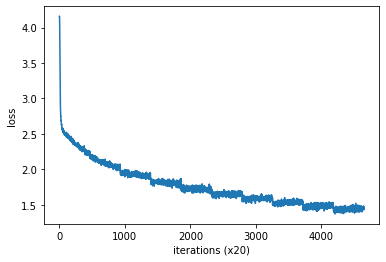

In [233]:
# 开始学习
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

运行起来非常慢

![](../../images/4-25.png)

这次我们利用的 PTB 语料库比之前要大得多，因此学习需要很长时间（半天左右）。

作为一种选择，我们提供了使用 GPU 运行的模式。如果要使用 GPU 运行，需要打开顶部的“# config.GPU = True”。

不过，使用 GPU运行需要有一台安装了 NVIDIA GPU 和 CuPy 的机器。

In [234]:
# 保存必要数据，以便后续使用
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)

In [235]:
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl'  # or 'skipgram_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

在学习结束后，取出权重（输入侧的权重），并保存在文件中以备后用（用于单词和单词 ID 之间的转化的字典也一起保存）。

这里，使用 Python的 pickle 功能进行文件保存。pickle 可以将 Python 代码中的对象保存到文件中（或者从文件中读取对象）

ch04/cbow_params.pkl中提供了学习好的参数。

如果不想等学习结束，可以使用本书提供的学习好的参数。

根据学习环境的不同，学习到的权重数据也不一样。

这是由权重初始化时用到的随机初始值、mini-bath 的随机选取，以及负采样的随机抽样造成的。

因为这些随机性，最后得到的权重在各自的环境中会不一样。

不过宏观来看，得到的结果（趋势）是类似的。

<div class="alert alert-danger alertdanger" style="margin-top: 0px">
    
**注意！！**

如果使用GPU则需要修改代码

https://www.ituring.com.cn/book/2678#reply-item-33298

https://docs.cupy.dev/en/stable/upgrade.html#cupy-v7
    
https://crieit.net/posts/module-cupy-has-no-attribute-scatter-add

![](../../images/bq15.jpg)

### COBW模型的评价

现在，我们来评价一下上一节学习到的单词的分布式表示。这里我们
使用第 2 章中实现的 most_similar() 函数，显示几个单词的最接近的单词

In [236]:
# ch04/eval.py
from common.util import most_similar, analogy
import pickle

In [237]:
pkl_file = './ch04/cbow_params.pkl' # 作者训练的
# pkl_file = 'cbow_params.pkl' # 我训练的
# pkl_file = 'skipgram_params.pkl'

with open(pkl_file, 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']

首先，在查询 you

In [238]:
querys = ['you', 'year', 'car', 'toyota']
most_similar(querys[0], word_to_id, id_to_word, word_vecs, top=5)


[query] you
 we: 0.74609375
 i: 0.6748046875
 your: 0.6455078125
 they: 0.60595703125
 weird: 0.58740234375


近似单词中出现了人称代词 i（= I）和 we

In [239]:
most_similar(querys[1], word_to_id, id_to_word, word_vecs, top=5)


[query] year
 month: 0.83447265625
 week: 0.77978515625
 summer: 0.76220703125
 spring: 0.74365234375
 decade: 0.71728515625


In [240]:
most_similar(querys[2], word_to_id, id_to_word, word_vecs, top=5)


[query] car
 window: 0.599609375
 auto: 0.572265625
 luxury: 0.564453125
 vehicle: 0.55419921875
 truck: 0.55029296875


接着，查询 year，可以看到 month、week 等表示时间区间的具有相同性质的单词。

In [241]:
most_similar(querys[3], word_to_id, id_to_word, word_vecs, top=5)


[query] toyota
 honda: 0.63134765625
 digital: 0.62548828125
 engines: 0.615234375
 coated: 0.6064453125
 chevrolet: 0.60302734375


然后，查询 toyota，可以得到 ford、mazda 和 nissan 等表示汽车制造商的词汇。

从这些结果可以看出，由CBOW 模型获得的单词的分布式表示具有良好的性质。

此外，由 word2vec 获得的单词的分布式表示不仅可以将近似单词聚拢在一起，还可以捕获更复杂的模式

其中一个具有代表性的例子是因“king − man + woman = queen”而出名的类推问题（类比问题）。

使用 word2vec 的单词的分布式表示，可以通过向量的加减法来解决类推问题。

需要在单词向量空间上寻找尽可能使“man → woman”向量和“king → ?”向量接近的单词。

![](../../images/4-20.png)

这里用 vec(‘man’) 表示单词 man 的分布式表示（单词向量）。如此一来，
图 4-20 中要求的关联性可以用数学式表示为 vec(‘woman’) − vec(‘man’) = 
vec(?) − vec(‘king’)。将其变形，有 vec(‘king’) + vec(‘woman’) − vec(‘man’) = 
vec(?)。也就是说，我们的任务是找到离向量 vec(‘king’) + vec(‘woman’) −
vec(‘man’) 最近的单词向量。本书在 common/util.py 中提供了实现此逻辑
的函数 analogy()。使用这个函数，可以用 analogy('man', 'king', 'woman', 
word_to_id, id_to_word, word_vecs, top=5) 这样 1 行代码来回答刚才的类推
问题。此时，输出的结果如下所示。

In [242]:
analogy('king', 'man', 'queen',  word_to_id, id_to_word, word_vecs)


[analogy] king:man = queen:?
 woman: 5.4609375
 a.m: 5.12109375
 text: 4.90234375
 yard: 4.8671875
 daughter: 4.7734375


第 1 个问题是“king : man = queen : ?”，这里正确地回答了“woman”。

In [243]:
analogy('take', 'took', 'go',  word_to_id, id_to_word, word_vecs)


[analogy] take:took = go:?
 eurodollars: 4.7421875
 're: 4.38671875
 came: 4.27734375
 was: 4.2265625
 went: 4.21484375


第 2 个问题是“take : took = go : ?”，也按预期回答了“went”。

这是捕获了现在时和过去时之间的模式的证据，可以解释为单词的分布式表示编码了时态相关的信息。

In [244]:
analogy('car', 'cars', 'child',  word_to_id, id_to_word, word_vecs)


[analogy] car:cars = child:?
 a.m: 5.91796875
 rape: 5.359375
 children: 5.19140625
 incest: 4.85546875
 bond-equivalent: 4.78515625


从第 3 题可知，单词的单数形式和复数形式之间的模式也被正确地捕获。

In [245]:
analogy('good', 'better', 'bad',  word_to_id, id_to_word, word_vecs)


[analogy] good:better = bad:?
 rather: 6.21484375
 more: 5.99609375
 less: 5.52734375
 greater: 4.390625
 faster: 4.25


可惜的是，对于第 4 题“good : better = bad : ?”，并没能回答出“worse”。

不过，看到 more、less 等比较级的单词出现在回答中，说明这些性质也被编码在了单词的分布式表示中。

像这样，使用 word2vec 获得的单词的分布式表示，可以通过向量的加减法求解类推问题。不仅限于单词的含义，它也捕获了语法中的模式。

另外，我们还在 word2vec 的单词的分布式表示中发现了一些有趣的结果，比如 good 和 best 之间存在 better 这样的关系

![](../../images/bq10.jpg)

这里的类推问题的结果看上去非常好。

不过遗憾的是，这是笔者特意选出来的能够被顺利解决的问题。

实际上，很多问题都无法获得预期的结果。

这是因为 PTB 数据集的规模还是比较小。

如果使用更大规模的语料库，可以获得更准确、更可靠的单词的分布式表示，从而大大提高类推问题的准确率

## wordvec相关的其他话题

### word2vec的应用例

#### 任务流程

在解决自然语言处理任务时，一般不会使用 word2vec 从零开始学习单词的分布式表示，而是先在大规模语料库（Wikipedia、Google News 等文本数据）上学习，然后将学习好的分布式表示应用于某个单独的任务。

比如，在文本分类、文本聚类、词性标注和情感分析等自然语言处理任务中，第一步的单词向量化工作就可以使用学习好的单词的分布式表示。

在几乎所有类型的自然语言处理任务中，单词的分布式表示都有很好的效果！

单词的分布式表示的学习和机器学习系统的学习通常使用不同的数据集独立进行。

比如，单词的分布式表示使用Wikipedia 等通用语料库预先学习好，然后机器学习系统（SVM 等）再使用针对当前问题收集到的数据进行学习。

但是，如果当前我们面对的问题存在大量的学习数据，则也可以考虑从零开始同时进行单词的分布式表示和机器学习系统的学习。

![](../../images/4-21.png)

#### 也可以将文档（单词序列）转化为固定长度的向量。

目前，关于如何将文档转化为固定长度的向量，相关研究已经进行了很多，最简单的方法是，把文档的各个单词转化为分布式表示，然后求它们的总和。

这是一种被称为 bag-of-words 的不考虑单词顺序的模型（思想）。

#### 比如对用户发来的邮件（吐槽等）自动进行分类的系统。

你想根据邮件的内容将用户情感分为 3 类。

![](../../images/4-22.png)

要开发邮件自动分类系统，首先需要从收集数据（邮件）开始。

我们收集用户发送的邮件，并人工对邮件进行标注，打上表示 3类情感的标签（positive/neutral/negative）。

标注工作结束后，用学习好的word2vec 将邮件转化为向量。

然后，将向量化的邮件及其情感标签输入某个情感分类系统（SVM 或神经网络等）进行学习。

### 单词向量的评价方法

#### 单词的分布式表示的学习和分类系统的学习有时可能会分开进行

如果整个过程作为一个系统统一评价，比如要调查单词的分布式表示的维数如何影响最终的精度

- 首先需要进行单词的分布式表示的学习

- 然后再利用这个分布式表示进行另一个机器学习系统的学习。

在这种情况下，由于需要调试出对两个系统都最优的超参数，所以非常费时。


因此，单词的分布式表示的评价往往与实际应用分开进行。

#### 单词的分布式表示评价

此时，经常使用的评价指标有“相似度”和“类推问题”

单词相似度的评价通常使用人工创建的单词相似度评价集来评估。

比如，cat 和 animal 的相似度是 8，cat 和 car 的相似度是 2……类似这样，

用 0 ～ 10 的分数人工地对单词之间的相似度打分。

然后，比较人给出的分数和 word2vec 给出的余弦相似度，考察它们之间的相关性。

类推问题的评价是指，

基于诸如“king : queen = man : ?”这样的类
推问题，

根据正确率测量单词的分布式表示的优劣。

比如，论文 [27] 中给出了一个类推问题的评价结果，其部分内容如图 4-23 所示。

![](../../images/4-23.png)

实验变量

- word2vec 的模型

- 单词的分布式表示的维数

- 语料库的大小为参数进行了比较实验

比较指标

- Semantics列显示的是推断单词含义的类推问题（像“king : queen = actor : actress”这样询问单词含义的问题）的正确率

- Syntax 列是询问单词形态信息的问题，比如“bad : worst = good : best”

结论

- 模型不同，精度不同（根据语料库选择最佳的模型）

- 语料库越大，结果越好（始终需要大数据）

- 单词向量的维数必须适中（太大会导致精度变差）

基于类推问题可以在一定程度上衡量“是否正确理解了单词含义或语法问题”。

因此，在自然语言处理的应用中，能够高精度地解决类推问题的单词的分布式表示应该可以获得好的结果。

但是，单词的分布式表示的优劣对目标应用贡献多少（或者有无贡献），取决于待处理问题的具体情况，比如应用的类型或语料库的内容等。

也就是说，不能保证类推问题的评价高，目标应用的结果就一定好。这一点请一定注意。

## 小结

一点点加牛栏山，哈哈，精神又暖和~~容光焕发

感谢群里小伙伴的提问与互动，支持着我把这里看完，嘻嘻